In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

np.random.seed(42)

In [2]:
print(np.__version__)
print(plt.matplotlib.__version__)

1.26.4
3.8.4


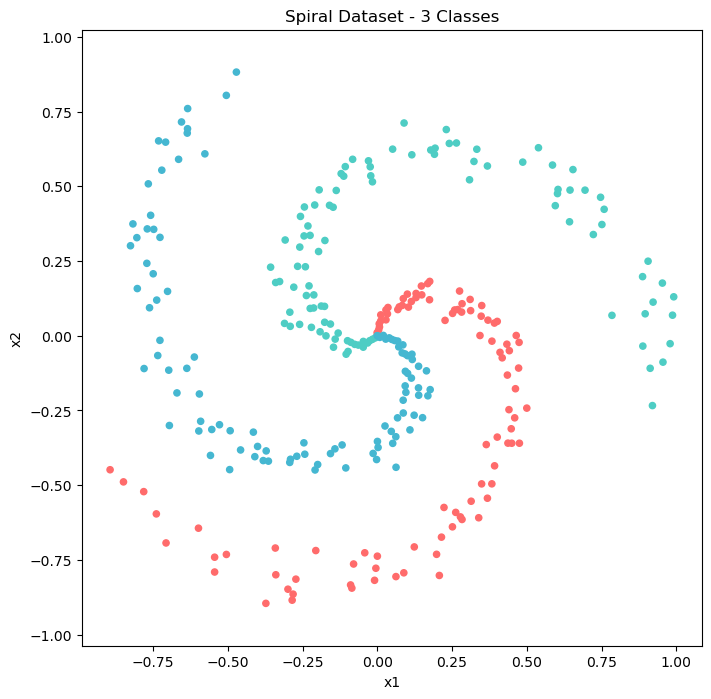

In [4]:
def generate_spiral_data(points_per_class=100, num_classes=3):
    """Generate a spiral dataset with N points per class."""
    # Create empty arrays to hold coordinates and labels
    X = np.zeros((points_per_class * num_classes, 2))
    y = np.zeros(points_per_class * num_classes, dtype=int)
    
    for class_idx in range(num_classes):
        start_idx = points_per_class * class_idx
        end_idx = points_per_class * (class_idx + 1)
        
        # r increases linearly: points start near center, end at edge
        r = np.linspace(0.0, 1, points_per_class)
        # theta sweeps each class through a unique angular range, with noise
        theta = np.linspace(
            class_idx * 4, (class_idx + 1) * 4, points_per_class
        ) + np.random.randn(points_per_class) * 0.2
        
        # Convert polar (r, theta) to Cartesian (x, y)
        X[start_idx:end_idx, 0] = r * np.sin(theta)
        X[start_idx:end_idx, 1] = r * np.cos(theta)
        y[start_idx:end_idx] = class_idx
    
    return X, y

# Generate the dataset
X, y = generate_spiral_data()

# Visualize the spiral data
plt.figure(figsize=(8, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=ListedColormap(['#FF6B6B', '#4ECDC4', '#45B7D1']), s=20)
plt.title('Spiral Dataset - 3 Classes')
plt.xlabel('x1')
plt.ylabel('x2')
plt.axis('equal')
plt.show()

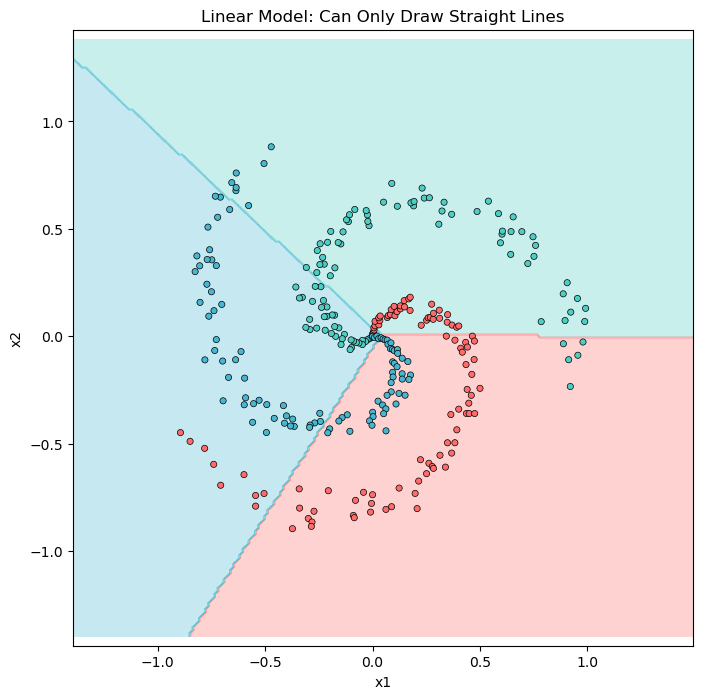

In [9]:
def linear_forward(X, W, b):
    """A model with NO activation function."""
    return X @ W + b

def softmax(Z):
    """Numerically stable softmax."""
    exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

# Train a linear model briefly
W_linear = np.random.randn(2, 3) * 0.01
b_linear = np.zeros((1, 3))

num_samples = X.shape[0]
y_one_hot = np.zeros((num_samples, 3))
y_one_hot[np.arange(num_samples), y] = 1

for i in range(1000):
    scores = linear_forward(X, W_linear, b_linear)
    probs = softmax(scores)
    
    dscores = (probs - y_one_hot) / num_samples
    dW = X.T @ dscores
    db = np.sum(dscores, axis=0, keepdims=True)
    
    W_linear -= 1.0 * dW
    b_linear -= 1.0 * db

# Plot linear decision boundary
def plot_decision_boundary(X, y, predict_fn, title):
    """Plot the decision boundary of a classifier."""
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = predict_fn(grid_points)
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(8, 8))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FF6B6B', '#4ECDC4', '#45B7D1']))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=ListedColormap(['#FF6B6B', '#4ECDC4', '#45B7D1']), s=20, edgecolors='k', linewidth=0.5)
    plt.title(title)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.axis('equal')
    plt.show()

def linear_predict(X_input):
    scores = linear_forward(X_input, W_linear, b_linear)
    return np.argmax(scores, axis=1)

plot_decision_boundary(X, y, linear_predict, 'Linear Model: Can Only Draw Straight Lines')

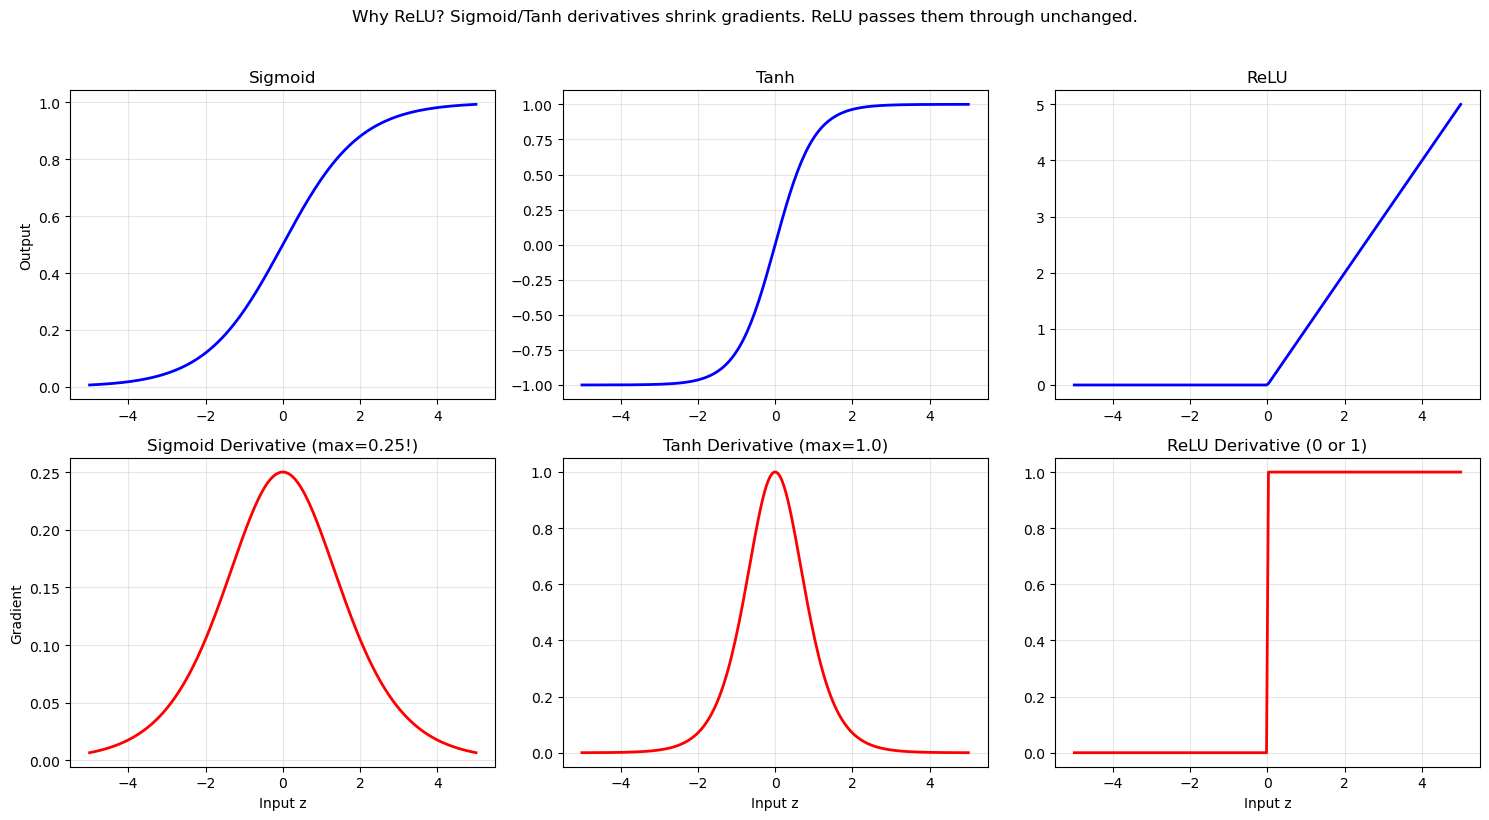

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

z = np.linspace(-5, 5, 200)

# Sigmoid
sigmoid_out = 1 / (1 + np.exp(-z))
sigmoid_deriv = sigmoid_out * (1 - sigmoid_out)
axes[0, 0].plot(z, sigmoid_out, 'b-', linewidth=2)
axes[0, 0].set_title('Sigmoid')
axes[0, 0].set_ylabel('Output')
axes[0, 0].grid(True, alpha=0.3)
axes[1, 0].plot(z, sigmoid_deriv, 'r-', linewidth=2)
axes[1, 0].set_title('Sigmoid Derivative (max=0.25!)')
axes[1, 0].set_ylabel('Gradient')
axes[1, 0].set_xlabel('Input z')
axes[1, 0].grid(True, alpha=0.3)

# Tanh
tanh_out = np.tanh(z)
tanh_deriv = 1 - tanh_out**2
axes[0, 1].plot(z, tanh_out, 'b-', linewidth=2)
axes[0, 1].set_title('Tanh')
axes[0, 1].grid(True, alpha=0.3)
axes[1, 1].plot(z, tanh_deriv, 'r-', linewidth=2)
axes[1, 1].set_title('Tanh Derivative (max=1.0)')
axes[1, 1].set_xlabel('Input z')
axes[1, 1].grid(True, alpha=0.3)

# ReLU
relu_out = np.maximum(0, z)
relu_deriv = (z > 0).astype(float)
axes[0, 2].plot(z, relu_out, 'b-', linewidth=2)
axes[0, 2].set_title('ReLU')
axes[0, 2].grid(True, alpha=0.3)
axes[1, 2].plot(z, relu_deriv, 'r-', linewidth=2)
axes[1, 2].set_title('ReLU Derivative (0 or 1)')
axes[1, 2].set_xlabel('Input z')
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle('Why ReLU? Sigmoid/Tanh derivatives shrink gradients. ReLU passes them through unchanged.', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [13]:
def relu(Z):
    """ReLU activation: max(0, Z)."""
    return np.maximum(0, Z)

def initialize_parameters(input_size, hidden_size, output_size):
    """He initialization for weights, zeros for biases."""
    params = {
        'W1': np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size),
        'b1': np.zeros((1, hidden_size)),
        'W2': np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size),
        'b2': np.zeros((1, output_size))
    }
    return params

def forward(X, params):
    """Forward pass: input -> hidden (ReLU) -> output (softmax)."""
    Z1 = X @ params['W1'] + params['b1']
    A1 = relu(Z1)
    Z2 = A1 @ params['W2'] + params['b2']
    A2 = softmax(Z2)

    cache = {'Z1': Z1, 'A1': A1, 'Z2': Z2, 'A2': A2}
    return A2, cache

def compute_loss(A2, Y_one_hot):
    """Cross-entropy loss."""
    m = Y_one_hot.shape[0]
    loss = -np.sum(Y_one_hot * np.log(A2 + 1e-8)) / m
    return loss

def backward(X, Y_one_hot, params, cache):
    """Backpropagation: compute gradients for all parameters."""
    m = X.shape[0]
    A1 = cache['A1']
    A2 = cache['A2']
    Z1 = cache['Z1']

    # Output layer gradients
    dZ2 = A2 - Y_one_hot
    dW2 = A1.T @ dZ2 / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    # Hidden layer gradients
    dA1 = dZ2 @ params['W2'].T
    dZ1 = dA1 * (Z1 > 0)  # ReLU derivative
    dW1 = X.T @ dZ1 / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    grads = {'dW1': dW1, 'db1': db1, 'dW2': dW2, 'db2': db2}
    return grads

def update_parameters(params, grads, learning_rate):
    """Gradient descent update."""
    params['W1'] -= learning_rate * grads['dW1']
    params['b1'] -= learning_rate * grads['db1']
    params['W2'] -= learning_rate * grads['dW2']
    params['b2'] -= learning_rate * grads['db2']
    return params



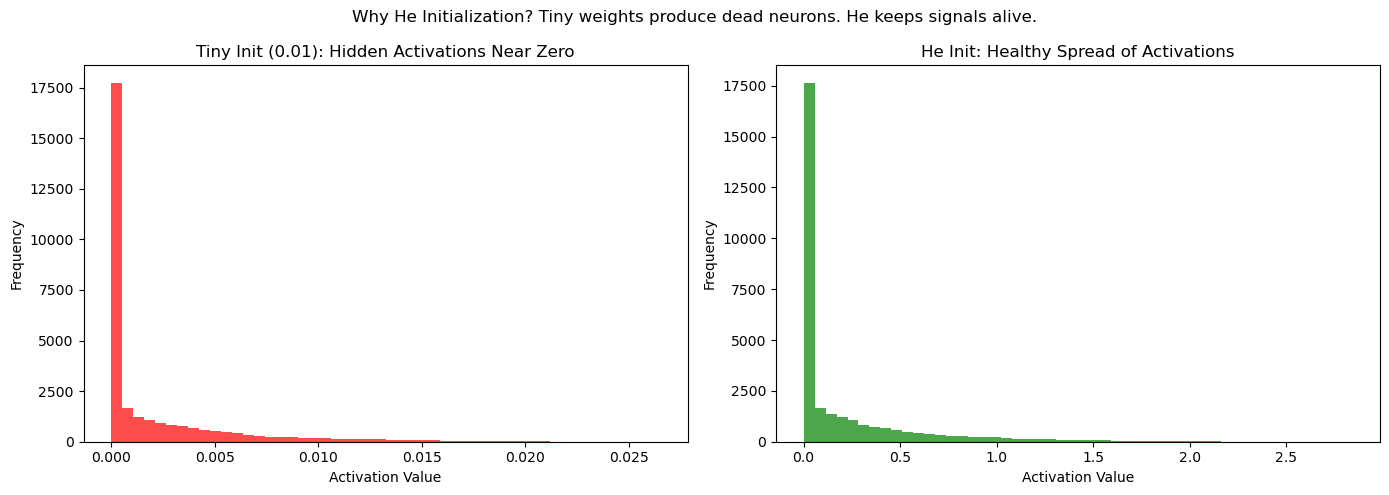

In [14]:
#Visualizing He Initialization vs Tiny Weights
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tiny weights
params_tiny = {
    'W1': np.random.randn(2, 100) * 0.01,
    'b1': np.zeros((1, 100)),
    'W2': np.random.randn(100, 3) * 0.01,
    'b2': np.zeros((1, 3))
}
_, cache_tiny = forward(X, params_tiny)
axes[0].hist(cache_tiny['A1'].ravel(), bins=50, color='red', alpha=0.7)
axes[0].set_title('Tiny Init (0.01): Hidden Activations Near Zero')
axes[0].set_xlabel('Activation Value')
axes[0].set_ylabel('Frequency')

# He initialization
params_he = initialize_parameters(2, 100, 3)
_, cache_he = forward(X, params_he)
axes[1].hist(cache_he['A1'].ravel(), bins=50, color='green', alpha=0.7)
axes[1].set_title('He Init: Healthy Spread of Activations')
axes[1].set_xlabel('Activation Value')
axes[1].set_ylabel('Frequency')

plt.suptitle('Why He Initialization? Tiny weights produce dead neurons. He keeps signals alive.', fontsize=12)
plt.tight_layout()
plt.show()

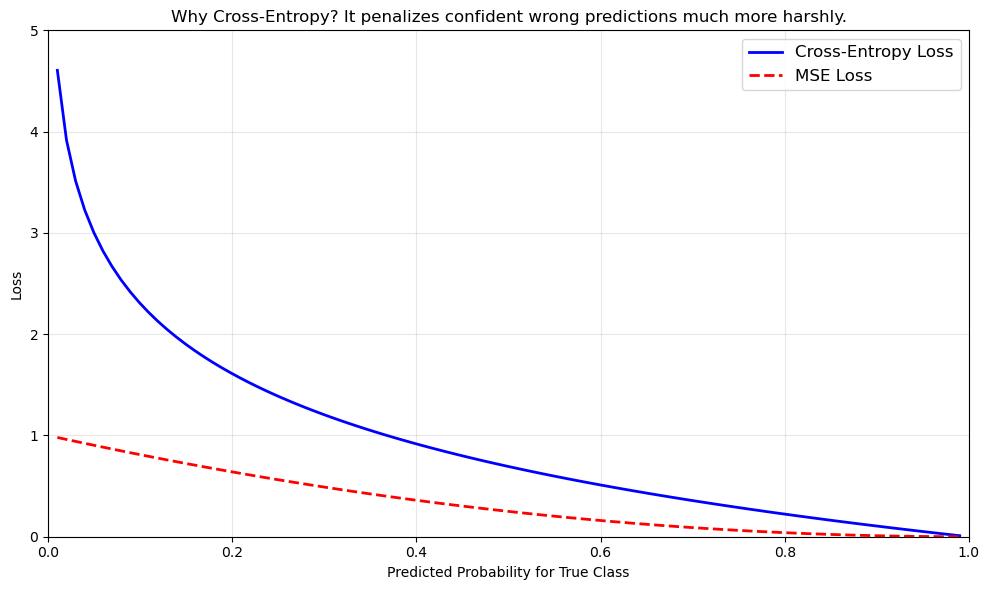

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

predicted_prob = np.linspace(0.01, 0.99, 100)
true_label = 1.0

ce_loss = -true_label * np.log(predicted_prob)
mse_loss = (true_label - predicted_prob) ** 2

ce_grad = -true_label / predicted_prob
mse_grad = -2 * (true_label - predicted_prob)

ax.plot(predicted_prob, ce_loss, 'b-', linewidth=2, label='Cross-Entropy Loss')
ax.plot(predicted_prob, mse_loss, 'r--', linewidth=2, label='MSE Loss')
ax.set_xlabel('Predicted Probability for True Class')
ax.set_ylabel('Loss')
ax.set_title('Why Cross-Entropy? It penalizes confident wrong predictions much more harshly.')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 5)
plt.tight_layout()
plt.show()

In [16]:
#Training Loop
def train(X, y, hidden_size=100, learning_rate=1.0, epochs=1000, verbose=True):
    num_classes = len(np.unique(y))
    m = X.shape[0]
    Y_one_hot = np.zeros((m, num_classes))
    Y_one_hot[np.arange(m), y] = 1
    params = initialize_parameters(X.shape[1], hidden_size, num_classes)
    history = {'loss': [], 'accuracy': [], 'params_snapshots': []}
    for epoch in range(epochs):
        A2, cache = forward(X, params)
        loss = compute_loss(A2, Y_one_hot)
        predictions = np.argmax(A2, axis=1)
        accuracy = np.mean(predictions == y)
        history['loss'].append(loss)
        history['accuracy'].append(accuracy)
        if epoch % 20 == 0:
            snapshot = {k: v.copy() for k, v in params.items()}
            history['params_snapshots'].append((epoch, snapshot))
        grads = backward(X, Y_one_hot, params, cache)
        params = update_parameters(params, grads, learning_rate)
        if verbose and epoch % 100 == 0:
            print(f"Epoch {epoch:4d} | Loss: {loss:.4f} | Accuracy: {accuracy:.4f}")
    return params, history

params_trained, history = train(X, y, hidden_size=100, learning_rate=1.0, epochs=1000)

Epoch    0 | Loss: 1.5029 | Accuracy: 0.1567
Epoch  100 | Loss: 0.1895 | Accuracy: 0.9600
Epoch  200 | Loss: 0.1220 | Accuracy: 0.9833
Epoch  300 | Loss: 0.0952 | Accuracy: 0.9900
Epoch  400 | Loss: 0.0800 | Accuracy: 0.9900
Epoch  500 | Loss: 0.0701 | Accuracy: 0.9900
Epoch  600 | Loss: 0.0630 | Accuracy: 0.9900
Epoch  700 | Loss: 0.0576 | Accuracy: 0.9900
Epoch  800 | Loss: 0.0534 | Accuracy: 0.9900
Epoch  900 | Loss: 0.0500 | Accuracy: 0.9933


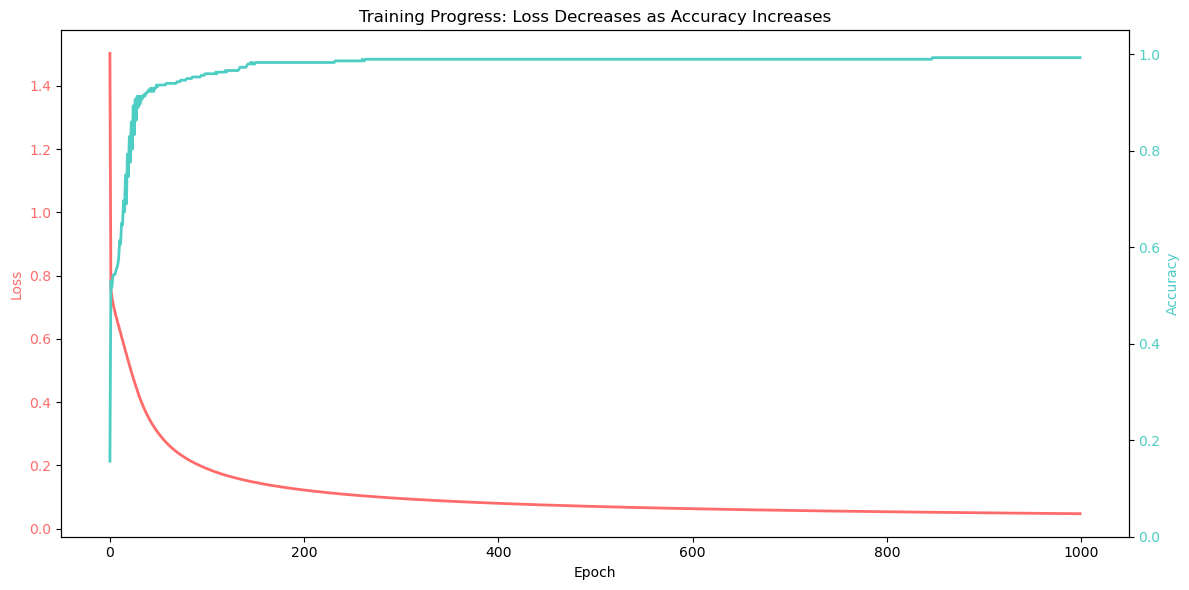

In [17]:
fig, ax1 = plt.subplots(figsize=(12, 6))
color_loss = '#FF6B6B'
color_acc = '#4ECDC4'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color=color_loss)
ax1.plot(history['loss'], color=color_loss, linewidth=2, label='Loss')
ax1.tick_params(axis='y', labelcolor=color_loss)
ax2 = ax1.twinx()
ax2.set_ylabel('Accuracy', color=color_acc)
ax2.plot(history['accuracy'], color=color_acc, linewidth=2, label='Accuracy')
ax2.tick_params(axis='y', labelcolor=color_acc)
ax2.set_ylim(0, 1.05)
plt.title('Training Progress: Loss Decreases as Accuracy Increases')
fig.tight_layout()
plt.show()

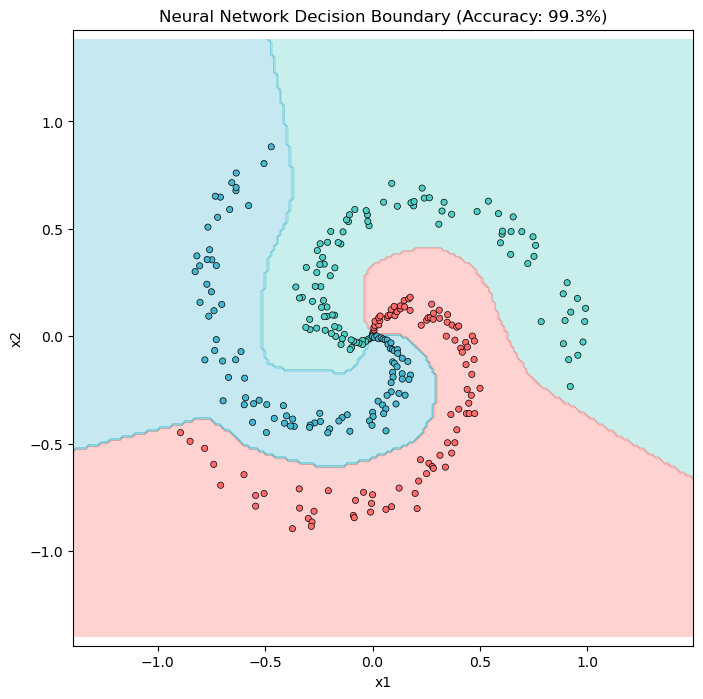

In [18]:
#Plotting the Final Decision Boundary
def nn_predict(X_input):
    A2, _ = forward(X_input, params_trained)
    return np.argmax(A2, axis=1)

plot_decision_boundary(X, y, nn_predict, f'Neural Network Decision Boundary (Accuracy: {history["accuracy"][-1]:.1%})')

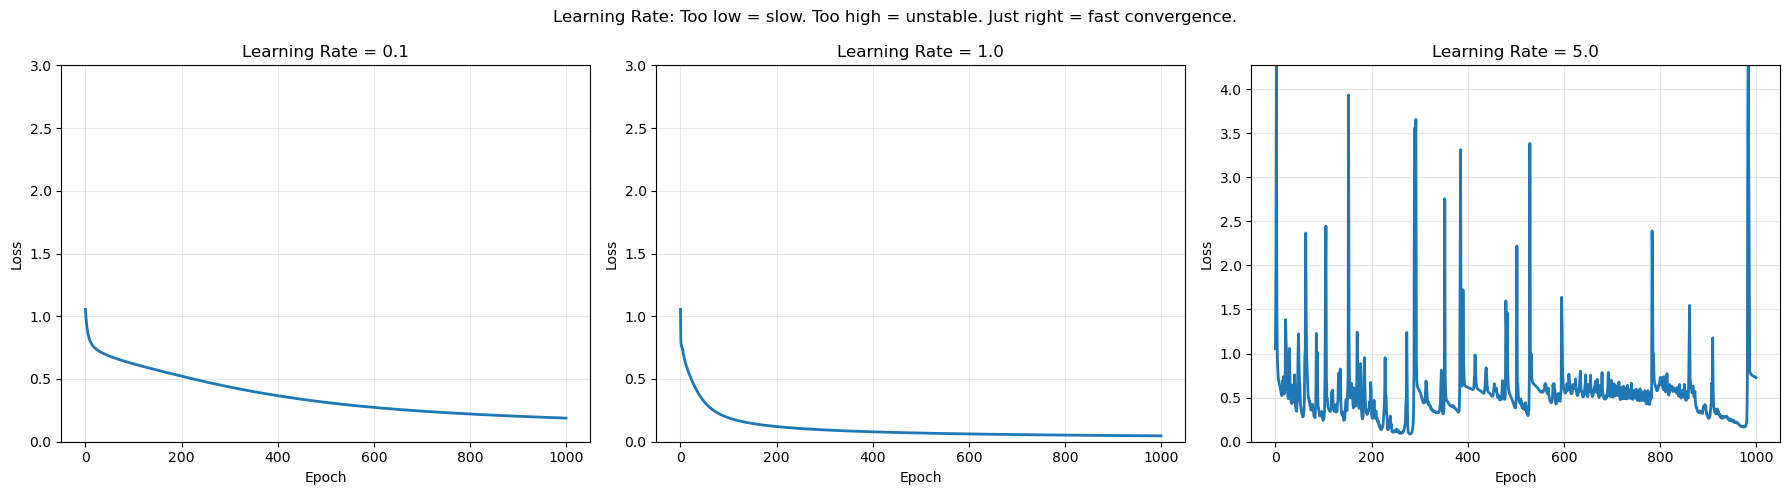

In [19]:
#Learning Rate Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
learning_rates = [0.1, 1.0, 5.0]

for idx, lr in enumerate(learning_rates):
    np.random.seed(42)
    _, hist = train(X, y, hidden_size=100, learning_rate=lr, epochs=1000, verbose=False)
    axes[idx].plot(hist['loss'], linewidth=2)
    axes[idx].set_title(f'Learning Rate = {lr}')
    axes[idx].set_xlabel('Epoch')
    axes[idx].set_ylabel('Loss')
    axes[idx].set_ylim(0, max(3.0, max(hist['loss'][:100])))
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Learning Rate: Too low = slow. Too high = unstable. Just right = fast convergence.', fontsize=12)
plt.tight_layout()
plt.show()

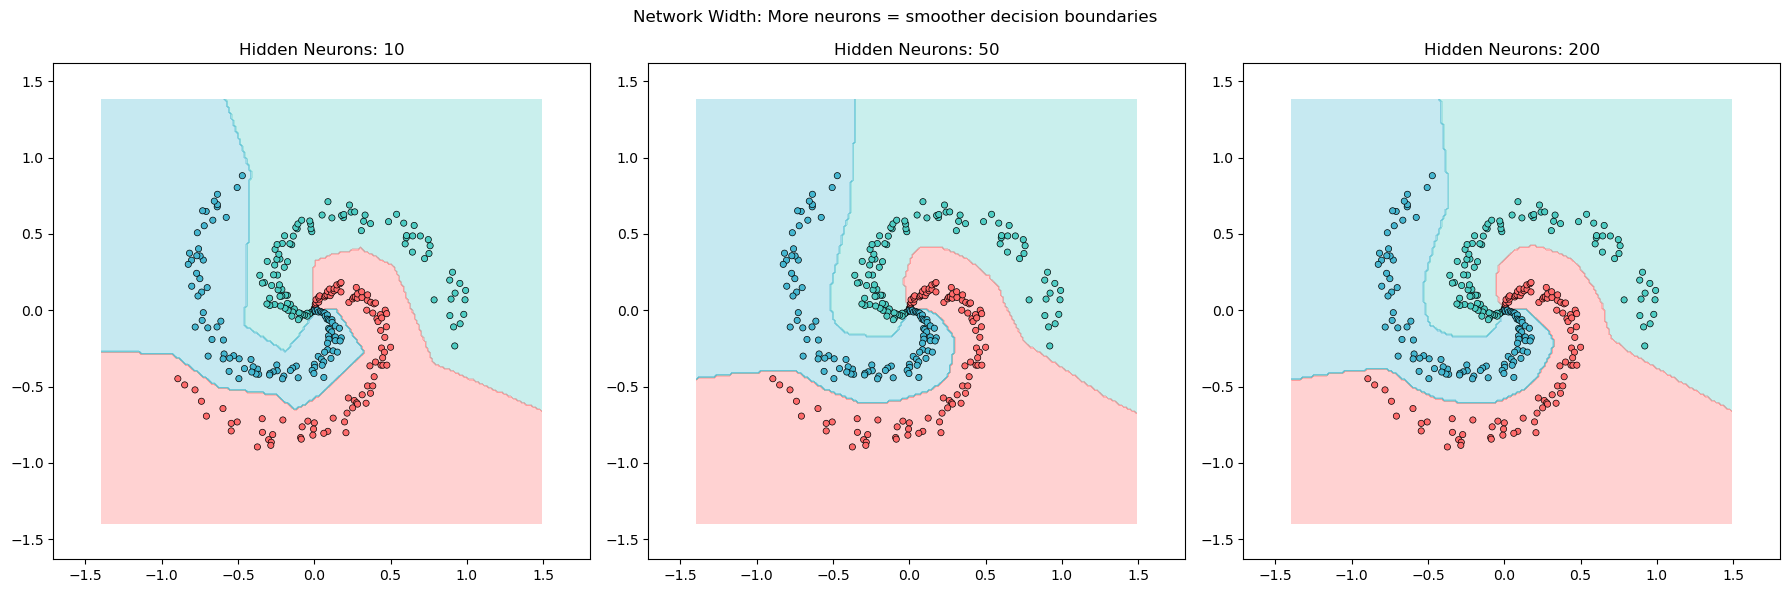

In [20]:
#Network Width Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
hidden_sizes = [10, 50, 200]

for idx, hs in enumerate(hidden_sizes):
    np.random.seed(42)
    params_exp, _ = train(X, y, hidden_size=hs, learning_rate=1.0, epochs=1000, verbose=False)
    
    # Decision boundary
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    
    A2_grid, _ = forward(grid_points, params_exp)
    Z_grid = np.argmax(A2_grid, axis=1).reshape(xx.shape)
    
    axes[idx].contourf(xx, yy, Z_grid, alpha=0.3, cmap=ListedColormap(['#FF6B6B', '#4ECDC4', '#45B7D1']))
    axes[idx].scatter(X[:, 0], X[:, 1], c=y, cmap=ListedColormap(['#FF6B6B', '#4ECDC4', '#45B7D1']), s=20, edgecolors='k', linewidth=0.5)
    axes[idx].set_title(f'Hidden Neurons: {hs}')
    axes[idx].axis('equal')

plt.suptitle('Network Width: More neurons = smoother decision boundaries', fontsize=12)
plt.tight_layout()
plt.show()

In [21]:
!pip install Pillow


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\Lenovo Legion\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


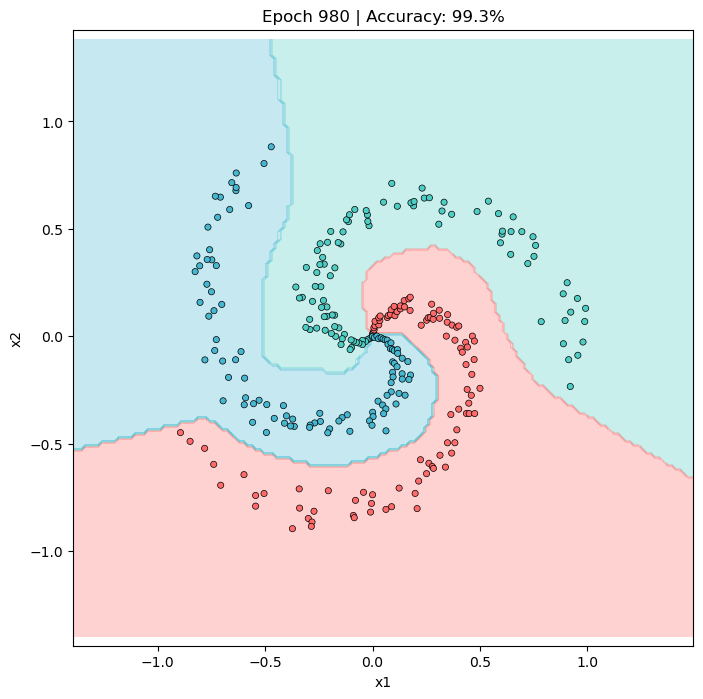

Animation saved as 'decision_boundary_evolution.gif'


In [22]:
# Cell 13: Animate Decision Boundary Evolution
from matplotlib.animation import FuncAnimation, PillowWriter

fig_anim, ax_anim = plt.subplots(figsize=(8, 8))

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 150), np.linspace(y_min, y_max, 150))
grid_points = np.c_[xx.ravel(), yy.ravel()]

snapshots = history['params_snapshots']

def animate(frame_idx):
    ax_anim.clear()
    epoch, snap_params = snapshots[frame_idx]
    A2_grid, _ = forward(grid_points, snap_params)
    Z_grid = np.argmax(A2_grid, axis=1).reshape(xx.shape)
    ax_anim.contourf(xx, yy, Z_grid, alpha=0.3, cmap=ListedColormap(['#FF6B6B', '#4ECDC4', '#45B7D1']))
    ax_anim.scatter(X[:, 0], X[:, 1], c=y, cmap=ListedColormap(['#FF6B6B', '#4ECDC4', '#45B7D1']), s=20, edgecolors='k', linewidth=0.5)
    ax_anim.set_title(f'Epoch {epoch} | Accuracy: {history["accuracy"][epoch]:.1%}')
    ax_anim.set_xlabel('x1')
    ax_anim.set_ylabel('x2')
    ax_anim.axis('equal')

anim = FuncAnimation(fig_anim, animate, frames=len(snapshots), interval=100, repeat=True)

anim.save('decision_boundary_evolution.gif', writer=PillowWriter(fps=10))

plt.show()
print("Animation saved as 'decision_boundary_evolution.gif'")